## Step 0 : Install packages

In [1]:
import subprocess
subprocess.run(["pip","install","cdsapi","xarray","netCDF4","pandas","matplotlib"], check=True)
print("Done!")

Done!


## Step 1 : Configuration

In [2]:
import os
import cdsapi
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

lat           = 34.499984
lon           = -4.708586
site_name     = "test_site"
years         = [2019, 2020, 2021, 2022, 2023]  # only 5 years
selected_year = 2021

print("Location:", lat, lon)
print("Years:", years)

Location: 34.499984 -4.708586
Years: [2019, 2020, 2021, 2022, 2023]


## Step 2 : Download ERA5 (one year at a time)

In [3]:
c = cdsapi.Client()
downloaded_files = []

for year in years:
    filename = site_name + "_" + str(year) + ".nc"
    downloaded_files.append(filename)

    if os.path.exists(filename):
        print("Skip (exists):", filename)
        continue

    print("Downloading:", year, "...")
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable":     "2m_temperature",
            "year":         str(year),
            "month":        [str(m).zfill(2) for m in range(1,13)],
            "day":          [str(d).zfill(2) for d in range(1,32)],
            "time":         ["00:00","06:00","12:00","18:00"],
            "area":         [lat+0.25, lon-0.25, lat-0.25, lon+0.25],
            "data_format":  "netcdf",
        },
        filename
    )
    print("Done:", year)

print("All downloaded!")

Downloading: 2019 ...


2026-06-04 10:18:25,090 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-06-04 10:18:25,093 INFO Request ID is 90c2c299-72bc-4cf9-8070-4a9d7c8102ed
2026-06-04 10:18:25,187 INFO status has been updated to accepted
2026-06-04 10:18:46,687 INFO status has been updated to successful


69efb3bb2650e13ed453b224092677bf.nc:   0%|          | 0.00/137k [00:00<?, ?B/s]

Done: 2019
Downloading: 2020 ...


2026-06-04 10:18:54,998 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-06-04 10:18:55,000 INFO Request ID is 16c406f4-5816-4fc0-9802-ffab7e074728
2026-06-04 10:18:56,467 INFO status has been updated to accepted
2026-06-04 10:20:22,123 INFO status has been updated to successful


...

59a0eb395ce25574109e4a215f984bf1.nc:   0%|          | 0.00/137k [00:00<?, ?B/s]

Done: 2022
Downloading: 2023 ...


2026-06-04 10:21:15,620 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-06-04 10:21:15,622 INFO Request ID is 7bbd5107-da47-4782-8a76-6406d1b61899
2026-06-04 10:21:17,526 INFO status has been updated to accepted
2026-06-04 10:21:33,636 INFO status has been updated to successful


591822b36d0f829b6b10ed7f546369e3.nc:   0%|          | 0.00/137k [00:00<?, ?B/s]

Done: 2023
All downloaded!


## Step 3 : Process into daily temperatures

In [4]:
all_dfs = []

for filename in downloaded_files:
    ds   = xr.open_dataset(filename)
    temp = ds["t2m"]
    tp   = temp.sel(latitude=lat, longitude=lon, method="nearest")
    df   = tp.to_dataframe(name="tk").reset_index()
    df["temperature"] = df["tk"] - 273.15
    tcol = "valid_time" if "valid_time" in df.columns else "time"
    df["date"] = pd.to_datetime(df[tcol])
    df = df[["date","temperature"]].copy()
    all_dfs.append(df)
    ds.close()

combined      = pd.concat(all_dfs, ignore_index=True)
combined["date"] = combined["date"].dt.date
daily         = combined.groupby("date")["temperature"].mean().reset_index()
daily.columns = ["date","temperature"]
daily["date"] = pd.to_datetime(daily["date"])

print("Total days:", len(daily))
print("Min:", round(daily["temperature"].min(),2), "C")
print("Max:", round(daily["temperature"].max(),2), "C")
daily.head(10)

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\xarray\backends\plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


Total days: 1826
Min: 6.34 C
Max: 35.98 C


,date,temperature
0,2019-01-01,11.176048
1,2019-01-02,10.794731
2,2019-01-03,11.367516
3,2019-01-04,11.274895
4,2019-01-05,10.678818
5,2019-01-06,9.036522
6,2019-01-07,10.651169
7,2019-01-08,8.192505
8,2019-01-09,7.832443
9,2019-01-10,9.681900


## Step 4 :  Analysis

In [5]:
daily["year"] = daily["date"].dt.year
yearly        = daily.groupby("year")["temperature"].mean()

best_year  = int(yearly.idxmax())
worst_year = int(yearly.idxmin())

print("=" * 40)
print("Best  year (hottest):", best_year,  "-->", round(yearly[best_year],2),  "C")
print("Worst year (coldest):", worst_year, "-->", round(yearly[worst_year],2), "C")

if selected_year in yearly.index:
    sel = daily[daily["year"] == selected_year]
    print("Selected year:", selected_year)
    print("  Average    :", round(yearly[selected_year],2), "C")
    print("  Hottest day:", round(sel["temperature"].max(),2), "C")
    print("  Coldest day:", round(sel["temperature"].min(),2), "C")

print("All years:")
for yr, avg in yearly.items():
    tag = ""
    if yr == best_year:     tag = " <- BEST"
    if yr == worst_year:    tag = " <- WORST"
    if yr == selected_year: tag = tag + " <- SELECTED"
    print(" ", yr, ":", round(avg,2), "C" + tag)
print("=" * 40)

Best  year (hottest): 2022 --> 20.5 C
Worst year (coldest): 2019 --> 18.93 C
Selected year: 2021
  Average    : 19.37 C
  Hottest day: 35.98 C
  Coldest day: 6.44 C
All years:
  2019 : 18.93 C <- WORST
  2020 : 19.85 C
  2021 : 19.37 C <- SELECTED
  2022 : 20.5 C <- BEST
  2023 : 20.41 C


## Step 5 : Save CSV

In [6]:
csv_file = site_name + "_temperature.csv"
daily.to_csv(csv_file, index=False)
print("Saved to:", csv_file)
daily.head()

Saved to: test_site_temperature.csv


,date,temperature,year
0,2019-01-01,11.176048,2019
1,2019-01-02,10.794731,2019
2,2019-01-03,11.367516,2019
3,2019-01-04,11.274895,2019
4,2019-01-05,10.678818,2019


## Step 6 — Plot

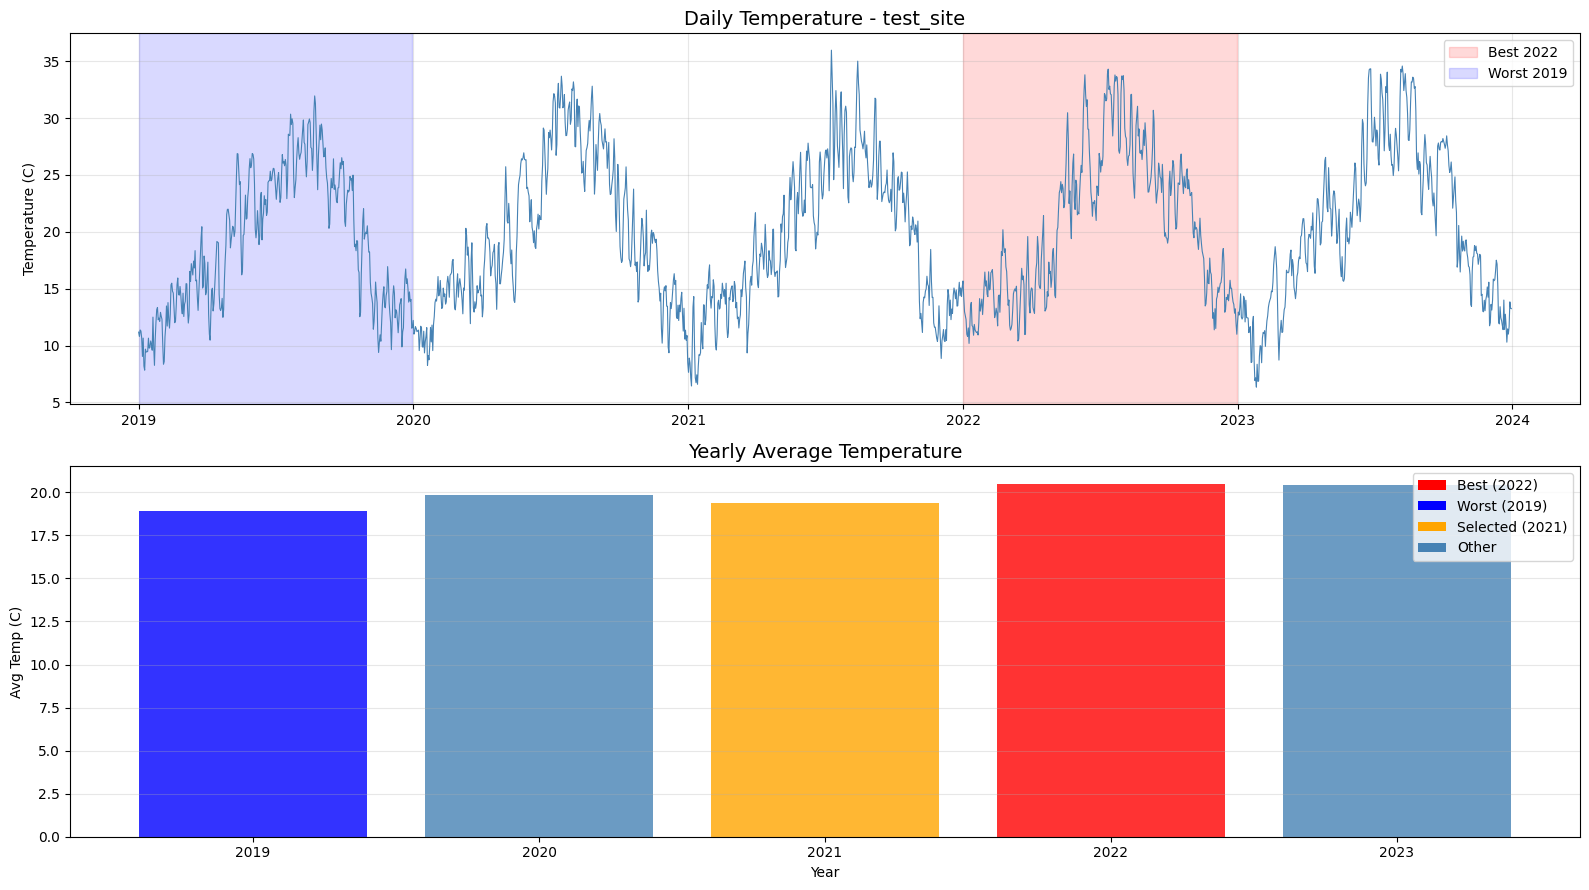

Plot saved!


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Plot 1 — daily temperature line
ax1 = axes[0]
ax1.plot(daily["date"], daily["temperature"], linewidth=0.8, color="steelblue")
ax1.set_title("Daily Temperature - " + site_name, fontsize=14)
ax1.set_ylabel("Temperature (C)")
ax1.grid(True, alpha=0.3)
for yr, color, label in [(best_year,"red","Best"),(worst_year,"blue","Worst")]:
    yd = daily[daily["date"].dt.year == yr]
    ax1.axvspan(yd["date"].min(), yd["date"].max(), alpha=0.15, color=color, label=label+" "+str(yr))
ax1.legend()

# Plot 2 — yearly bar chart
ax2 = axes[1]
colors = []
for yr in yearly.index:
    if yr == best_year:       colors.append("red")
    elif yr == worst_year:    colors.append("blue")
    elif yr == selected_year: colors.append("orange")
    else:                     colors.append("steelblue")
ax2.bar(yearly.index, yearly.values, color=colors, alpha=0.8)
ax2.set_title("Yearly Average Temperature", fontsize=14)
ax2.set_xlabel("Year")
ax2.set_ylabel("Avg Temp (C)")
ax2.grid(True, alpha=0.3, axis="y")
ax2.legend(handles=[
    Patch(facecolor="red",       label="Best ("+str(best_year)+")"),
    Patch(facecolor="blue",      label="Worst ("+str(worst_year)+")"),
    Patch(facecolor="orange",    label="Selected ("+str(selected_year)+")"),
    Patch(facecolor="steelblue", label="Other"),
])
plt.tight_layout()
plt.savefig(site_name + "_plot.png", dpi=150)
plt.show()
print("Plot saved!")